# 🌧️ Nairobi Flood Risk — Data Cleaning & Model Training
**Hackathon Project** | Open-Meteo Historical Data → Cleaned CSV → Trained ML Model

### Steps
1. Fetch real Nairobi weather data from Open-Meteo
2. Clean & validate the raw data
3. Engineer flood prediction features
4. Label flood events
5. Train & evaluate the model
6. Save model files for the Flask server


## 0. Install Dependencies

In [1]:
# Run once — comment out after first run
%pip install requests pandas numpy scikit-learn joblib matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import joblib
import warnings
warnings.filterwarnings("ignore")

print(" All imports successful")

✅ All imports successful


## 2. Fetch Nairobi Historical Weather
Fetching 7 years of hourly data from Open-Meteo (free, no API key needed).  
Coordinates: **-1.286, 36.817** (Nairobi city centre)

In [3]:
url = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=-1.286&longitude=36.817"
    "&start_date=2018-01-01&end_date=2024-12-31"
    "&hourly=precipitation,rain,relativehumidity_2m,windspeed_10m,temperature_2m,cloudcover"
    "&timezone=Africa%2FNairobi"
)

print("Fetching data from Open-Meteo...")
r = requests.get(url, timeout=60)
r.raise_for_status()
data = r.json()

hourly = data["hourly"]
times  = hourly["time"]
print(f" Saved {len(times):,} hourly records (2018–2024)")

rows = []
for i, t in enumerate(times):
    dt = datetime.fromisoformat(t)
    rows.append({
        "datetime":         t,
        "date":             dt.strftime("%Y-%m-%d"),
        "hour":             dt.hour,
        "month":            dt.month,
        "day_of_year":      dt.timetuple().tm_yday,
        "latitude":         -1.286,
        "longitude":        36.817,
        "precipitation_mm": hourly["precipitation"][i] or 0.0,
        "rain_mm":          hourly["rain"][i] or 0.0,
        "humidity":         hourly["relativehumidity_2m"][i] or 0.0,
        "wind_speed":       hourly["windspeed_10m"][i] or 0.0,
        "temperature":      hourly["temperature_2m"][i] or 0.0,
        "cloud_cover":      hourly["cloudcover"][i] or 0.0,
    })

df_raw = pd.DataFrame(rows)
df_raw.to_csv("nairobi_raw.csv", index=False)
print(f" Saved nairobi_raw.csv — {len(df_raw):,} rows")
df_raw.head()

Fetching data from Open-Meteo...
✅ Received 61,368 hourly records (2018–2024)
✅ Saved nairobi_raw.csv — 61,368 rows


,datetime,date,hour,month,day_of_year,latitude,longitude,precipitation_mm,rain_mm,humidity,wind_speed,temperature,cloud_cover
0,2018-01-01T00:00,2018-01-01,0,1,1,-1.286,36.817,0.0,0.0,66,6.4,17.1,14.0
1,2018-01-01T01:00,2018-01-01,1,1,1,-1.286,36.817,0.0,0.0,66,8.0,17.0,15.0
2,2018-01-01T02:00,2018-01-01,2,1,1,-1.286,36.817,0.0,0.0,67,8.2,16.4,19.0
3,2018-01-01T03:00,2018-01-01,3,1,1,-1.286,36.817,0.0,0.0,68,8.4,16.2,2.0
4,2018-01-01T04:00,2018-01-01,4,1,1,-1.286,36.817,0.0,0.0,69,7.3,15.8,33.0


## 3. Inspect Raw Data

In [4]:
print("Shape:", df_raw.shape)
print("\nData types:")
print(df_raw.dtypes)
print("\nMissing values:")
print(df_raw.isnull().sum())
print("\nBasic stats:")
df_raw.describe().round(2)

Shape: (61368, 13)

Data types:
datetime                str
date                    str
hour                  int64
month                 int64
day_of_year           int64
latitude            float64
longitude           float64
precipitation_mm    float64
rain_mm             float64
humidity              int64
wind_speed          float64
temperature         float64
cloud_cover         float64
dtype: object

Missing values:
datetime            0
date                0
hour                0
month               0
day_of_year         0
latitude            0
longitude           0
precipitation_mm    0
rain_mm             0
humidity            0
wind_speed          0
temperature         0
cloud_cover         0
dtype: int64

Basic stats:


,hour,month,day_of_year,latitude,longitude,precipitation_mm,rain_mm,humidity,wind_speed,temperature,cloud_cover
count,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00
mean,11.50,6.52,183.14,-1.29,36.82,0.12,0.12,70.96,8.05,18.82,71.94
std,6.92,3.45,105.45,0.00,0.00,0.52,0.52,19.79,3.90,3.92,32.58
min,0.00,1.00,1.00,-1.29,36.82,0.00,0.00,11.00,0.00,8.10,0.00
25%,5.75,4.00,92.00,-1.29,36.82,0.00,0.00,55.00,5.30,15.90,45.00
50%,11.50,7.00,183.00,-1.29,36.82,0.00,0.00,74.00,7.35,17.80,89.00
75%,17.25,10.00,274.00,-1.29,36.82,0.10,0.10,89.00,10.20,21.80,100.00
max,23.00,12.00,366.00,-1.29,36.82,19.20,19.20,100.00,26.30,31.50,100.00


## 4. Clean the Data
- Parse datetimes
- Drop missing rainfall rows
- Remove outliers (negative rain, impossibly high values)
- Clip humidity and wind to valid ranges
- Remove duplicates

In [5]:
df = df_raw.copy()

before = len(df)

# Parse dates
df["datetime"] = pd.to_datetime(df["datetime"])
df["date"]     = pd.to_datetime(df["date"])

# Drop rows with missing rainfall (can't fill these)
df = df.dropna(subset=["precipitation_mm"])

# Remove impossible values
df = df[df["precipitation_mm"] >= 0]
df = df[df["precipitation_mm"] < 300]   # max realistic hourly mm

# Clip other columns to valid ranges
df["humidity"]    = df["humidity"].clip(0, 100)
df["wind_speed"]  = df["wind_speed"].clip(0, 100)
df["cloud_cover"] = df["cloud_cover"].clip(0, 100)

# Remove duplicates
df = df.drop_duplicates(subset=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

after = len(df)
print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Removed:     {before - after:,} bad rows")
print(f"\n Data is clean")
df.describe().round(2)

Rows before: 61,368
Rows after:  61,368
Removed:     0 bad rows

 Data is clean


,datetime,date,hour,month,day_of_year,latitude,longitude,precipitation_mm,rain_mm,humidity,wind_speed,temperature,cloud_cover
count,61368,61368,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00,61368.00
mean,2021-07-02 11:30:00,2021-07-02 00:00:00,11.50,6.52,183.14,-1.29,36.82,0.12,0.12,70.96,8.05,18.82,71.94
min,2018-01-01 00:00:00,2018-01-01 00:00:00,0.00,1.00,1.00,-1.29,36.82,0.00,0.00,11.00,0.00,8.10,0.00
25%,2019-10-02 05:45:00,2019-10-02 00:00:00,5.75,4.00,92.00,-1.29,36.82,0.00,0.00,55.00,5.30,15.90,45.00
50%,2021-07-02 11:30:00,2021-07-02 00:00:00,11.50,7.00,183.00,-1.29,36.82,0.00,0.00,74.00,7.35,17.80,89.00
75%,2023-04-02 17:15:00,2023-04-02 00:00:00,17.25,10.00,274.00,-1.29,36.82,0.10,0.10,89.00,10.20,21.80,100.00
max,2024-12-31 23:00:00,2024-12-31 00:00:00,23.00,12.00,366.00,-1.29,36.82,19.20,19.20,100.00,26.30,31.50,100.00
std,NaN,NaN,6.92,3.45,105.45,0.00,0.00,0.52,0.52,19.79,3.90,3.92,32.58


## 5. Visualize Rainfall Distribution

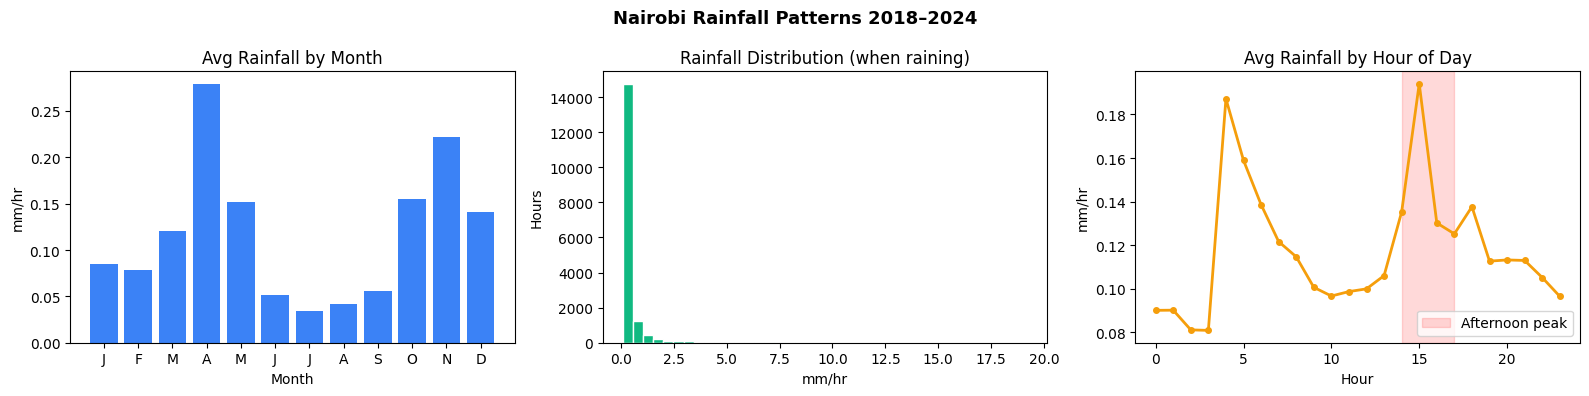

 Chart saved as rainfall_analysis.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Monthly average rainfall
monthly = df.groupby("month")["precipitation_mm"].mean()
axes[0].bar(monthly.index, monthly.values, color="#3B82F6")
axes[0].set_title("Avg Rainfall by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("mm/hr")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])

# Rainfall distribution (non-zero only)
rain_only = df[df["precipitation_mm"] > 0]["precipitation_mm"]
axes[1].hist(rain_only.clip(0, 50), bins=40, color="#10B981", edgecolor="white")
axes[1].set_title("Rainfall Distribution (when raining)")
axes[1].set_xlabel("mm/hr")
axes[1].set_ylabel("Hours")

# Hourly pattern
hourly_avg = df.groupby("hour")["precipitation_mm"].mean()
axes[2].plot(hourly_avg.index, hourly_avg.values, color="#F59E0B", linewidth=2, marker="o", markersize=4)
axes[2].set_title("Avg Rainfall by Hour of Day")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("mm/hr")
axes[2].axvspan(14, 17, alpha=0.15, color="red", label="Afternoon peak")
axes[2].legend()

plt.suptitle("Nairobi Rainfall Patterns 2018–2024", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rainfall_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print(" Chart saved as rainfall_analysis.png")

## 6. Feature Engineering
Key insight: **cumulative rainfall over time** is a much stronger flood predictor than current rainfall alone.
Nairobi floods when rain accumulates faster than drains can handle it.


In [7]:
# Rolling cumulative rain — strongest flood predictors
df["rain_3h_mm"]  = df["precipitation_mm"].rolling(3,  min_periods=1).sum()
df["rain_6h_mm"]  = df["precipitation_mm"].rolling(6,  min_periods=1).sum()
df["rain_24h_mm"] = df["precipitation_mm"].rolling(24, min_periods=1).sum()
df["rain_48h_mm"] = df["precipitation_mm"].rolling(48, min_periods=1).sum()

# Nairobi has TWO rainy seasons:
# Long rains: March–May | Short rains: October–December
df["is_rainy_season"] = df["month"].isin([3, 4, 5, 10, 11, 12]).astype(int)

# Afternoon convective storms are common in Nairobi (2pm–5pm)
df["is_afternoon"] = df["hour"].between(14, 17).astype(int)

print("New features added:")
new_cols = ["rain_3h_mm","rain_6h_mm","rain_24h_mm","rain_48h_mm","is_rainy_season","is_afternoon"]
print(df[new_cols].describe().round(2))

New features added:
       rain_3h_mm  rain_6h_mm  rain_24h_mm  rain_48h_mm  is_rainy_season  \
count    61368.00    61368.00     61368.00     61368.00          61368.0   
mean         0.35        0.71         2.83         5.66              0.5   
std          1.27        2.15         5.69         9.71              0.5   
min          0.00        0.00         0.00         0.00              0.0   
25%          0.00        0.00         0.10         0.40              0.0   
50%          0.00        0.10         0.80         1.90              1.0   
75%          0.20        0.60         3.00         6.70              1.0   
max         44.00       58.30        88.70       125.60              1.0   

       is_afternoon  
count      61368.00  
mean           0.17  
std            0.37  
min            0.00  
25%            0.00  
50%            0.00  
75%            0.00  
max            1.00  


## 7. Create Flood Label
A location is labelled as **flooding** when:
- Current hour rain > **10 mm/hr**, OR
- 3-hour cumulative rain > **25 mm**, OR
- 24-hour cumulative rain > **50 mm**

Adjust these thresholds based on domain knowledge of your specific zones.


Flood hours:    146 (0.2%)
No-flood hours: 61,222 (99.8%)


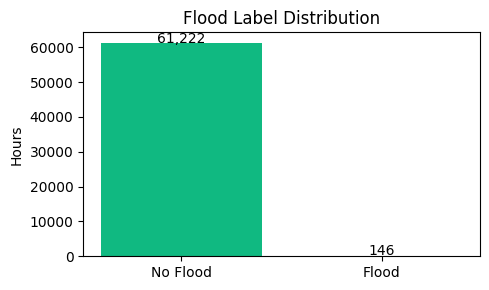

In [8]:
df["flood"] = (
    (df["precipitation_mm"] > 10) |
    (df["rain_3h_mm"]  > 25)      |
    (df["rain_24h_mm"] > 50)
).astype(int)

flood_count = df["flood"].sum()
total       = len(df)
print(f"Flood hours:    {flood_count:,} ({flood_count/total*100:.1f}%)")
print(f"No-flood hours: {total - flood_count:,} ({(total-flood_count)/total*100:.1f}%)")

# Class balance chart
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["No Flood", "Flood"], [total - flood_count, flood_count], color=["#10B981", "#EF4444"])
ax.set_title("Flood Label Distribution")
ax.set_ylabel("Hours")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Save Clean Dataset

In [9]:
KEEP_COLS = [
    "datetime","date","hour","month","day_of_year","latitude","longitude",
    "precipitation_mm","rain_mm","humidity","wind_speed","temperature","cloud_cover",
    "rain_3h_mm","rain_6h_mm","rain_24h_mm","rain_48h_mm",
    "is_rainy_season","is_afternoon","flood"
]

df_clean = df[KEEP_COLS]
df_clean.to_csv("nairobi_clean.csv", index=False)
print(f" Saved nairobi_clean.csv — {len(df_clean):,} rows, {len(KEEP_COLS)} columns")
df_clean.head()

 Saved nairobi_clean.csv — 61,368 rows, 20 columns


,datetime,date,hour,month,day_of_year,latitude,longitude,precipitation_mm,rain_mm,humidity,wind_speed,temperature,cloud_cover,rain_3h_mm,rain_6h_mm,rain_24h_mm,rain_48h_mm,is_rainy_season,is_afternoon,flood
0,2018-01-01 00:00:00,2018-01-01,0,1,1,-1.286,36.817,0.0,0.0,66,6.4,17.1,14.0,0.0,0.0,0.0,0.0,0,0,0
1,2018-01-01 01:00:00,2018-01-01,1,1,1,-1.286,36.817,0.0,0.0,66,8.0,17.0,15.0,0.0,0.0,0.0,0.0,0,0,0
2,2018-01-01 02:00:00,2018-01-01,2,1,1,-1.286,36.817,0.0,0.0,67,8.2,16.4,19.0,0.0,0.0,0.0,0.0,0,0,0
3,2018-01-01 03:00:00,2018-01-01,3,1,1,-1.286,36.817,0.0,0.0,68,8.4,16.2,2.0,0.0,0.0,0.0,0.0,0,0,0
4,2018-01-01 04:00:00,2018-01-01,4,1,1,-1.286,36.817,0.0,0.0,69,7.3,15.8,33.0,0.0,0.0,0.0,0.0,0,0,0


## 9. Train the Flood Prediction Model
Using **Gradient Boosting Classifier** — strong performance on tabular weather data.


In [10]:
FEATURES = [
    "precipitation_mm", "rain_3h_mm", "rain_6h_mm", "rain_24h_mm",
    "humidity", "wind_speed", "temperature", "cloud_cover",
    "month", "hour", "is_rainy_season", "is_afternoon",
    "latitude", "longitude"
]

X = df_clean[FEATURES]
y = df_clean["flood"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set: {len(X_train):,} rows")
print(f"Test set:     {len(X_test):,} rows")
print("\nTraining model...")

model = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train_s, y_train)
print("✅ Model trained!")

Training set: 49,094 rows
Test set:     12,274 rows

Training model...
✅ Model trained!


## 10. Evaluate Model Performance

=== Classification Report ===
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00     12245
       Flood       0.97      1.00      0.98        29

    accuracy                           1.00     12274
   macro avg       0.98      1.00      0.99     12274
weighted avg       1.00      1.00      1.00     12274

ROC-AUC Score: 1.0000


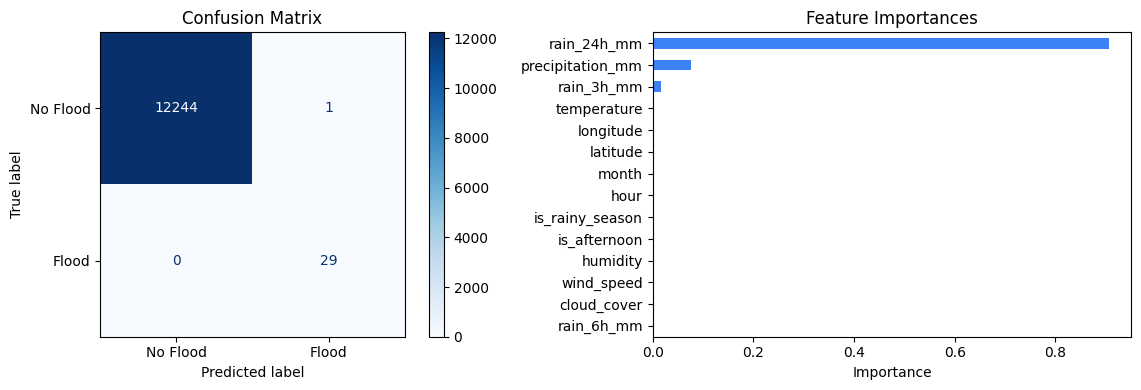

 Chart saved as model_evaluation.png


In [11]:
y_pred  = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["No Flood", "Flood"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Flood", "Flood"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

# Feature importances
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#3B82F6")
axes[1].set_title("Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()
print(" Chart saved as model_evaluation.png")

## 11. Save Model Files
These three files go into your `ml/` folder alongside `predict_server.py`.


In [12]:
joblib.dump(model,    "flood_model.pkl")
joblib.dump(scaler,   "scaler.pkl")
joblib.dump(FEATURES, "features.pkl")

print(" Saved:")
print("   flood_model.pkl  → trained model")
print("   scaler.pkl       → feature scaler")
print("   features.pkl     → feature list")
print("\nCopy these 3 files into your ml/ folder and run predict_server.py")

 Saved:
   flood_model.pkl  → trained model
   scaler.pkl       → feature scaler
   features.pkl     → feature list

Copy these 3 files into your ml/ folder and run predict_server.py
